In [1]:
%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'rpy2'

In [1]:
f1_data <- read.csv("f1-scores.csv")
f1_data

NameError: name 'f1_data' is not defined

In [ ]:
combos <- expand.grid(list(prompt=c("zero-shot","one-shot"),input=c("text","image")), stringsAsFactors=FALSE) 
combos$label <- apply(combos,1,paste,collapse=";")
combos

prompt,input,label
<chr>,<chr>,<chr>
zero-shot,text,zero-shot;text
one-shot,text,one-shot;text
zero-shot,image,zero-shot;image
one-shot,image,one-shot;image


In [ ]:
mnames <- unique(f1_data$model)
f1_mat <- do.call(rbind,lapply(mnames, \(m) {
    vals <- do.call(cbind,lapply(seq_len(nrow(combos)), \(i) {
        combo <- combos[i,]
        with(f1_data,f1[which(model == m & prompt == combo$prompt & input == combo$input)])
    }))
}))
rownames(f1_mat) <- mnames
colnames(f1_mat) <- combos$label
f1_mat

,zero-shot;text,one-shot;text,zero-shot;image,one-shot;image
GPT4.1-mini,63.0,66.6,20.1,21.1
Gemma3-27B,17.2,17.2,51.5,27.5
Llama3-170B,39.9,40.6,NA,NA
Mistral-24B,31.4,30.2,23.4,16.6
NuExtract-4B,27.9,NA,NA,NA
GliNER,6.2,NA,6.2,NA


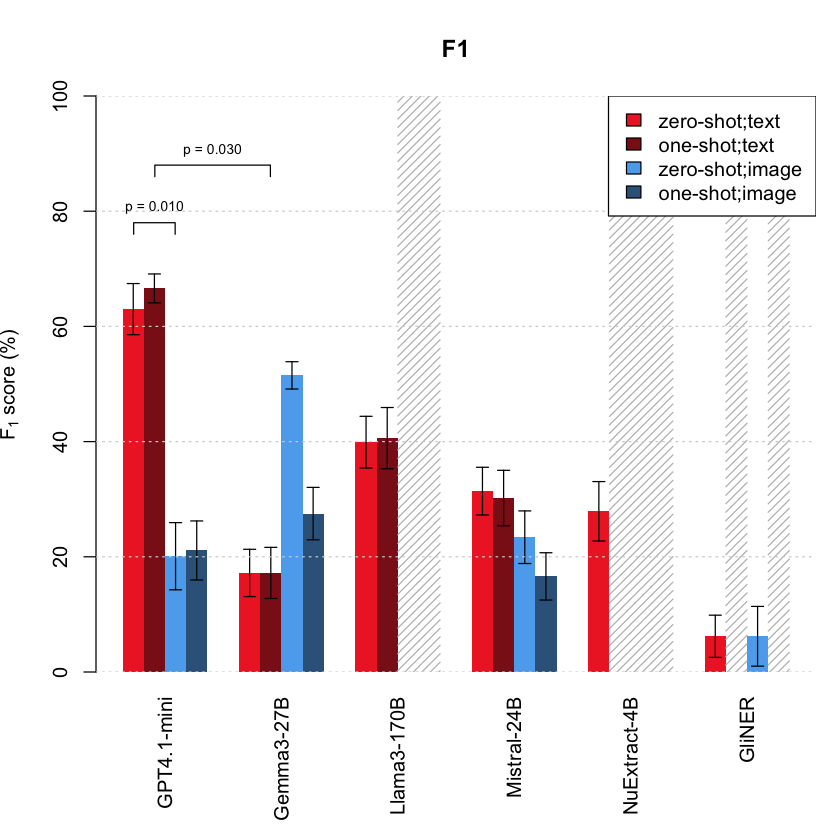

In [ ]:

#make up MOCK error values for now!!! TODO: Replace this with real data
stderr <- matrix(rnorm(6*4,10,2),nrow=4)
pvals <- c(0.03,0.01)

# mycolors <- expand.grid(list(c("firebrick", "darkolivegreen"), c(2,4)))|> apply(1,paste,collapse="")
mycolors <- c("firebrick2", "firebrick4", "steelblue2", "steelblue4")

# options(repr.plot.width = 2, repr.plot.height = 1)

#set margins and axis label orientations
op <- par(las=3, mar=c(7,4,4,1))
#draw plot
xs <- barplot(
    t(f1_mat), beside=TRUE, space=c(0,1.5),
    ylim=c(0,100),
    col=mycolors, border=NA, 
    ylab=expression(F[1]~"score (%)"), main="F1"
)
#draw the error bars
yogitools::errorBars(xs, t(f1_mat), stderr, l=.05)
#determine x-coordinates of missing values
xna <- xs[apply(t(f1_mat),1:2,is.na)]
#add hatching at missing value positions
rect(xna-0.5, 0, xna+0.5, 100, col="gray", density=20,border=NA)
drawPvalBracket(pvals[[1]], xs[2,1], xs[2,2], h = 88, th = 2)
drawPvalBracket(pvals[[2]], xs[1,1], xs[3,1], h = 78, th = 2)
#add grid lines
grid(NA,NULL)
#add legend
legend("topright", colnames(f1_mat), fill=mycolors, bg="white")

par(op)

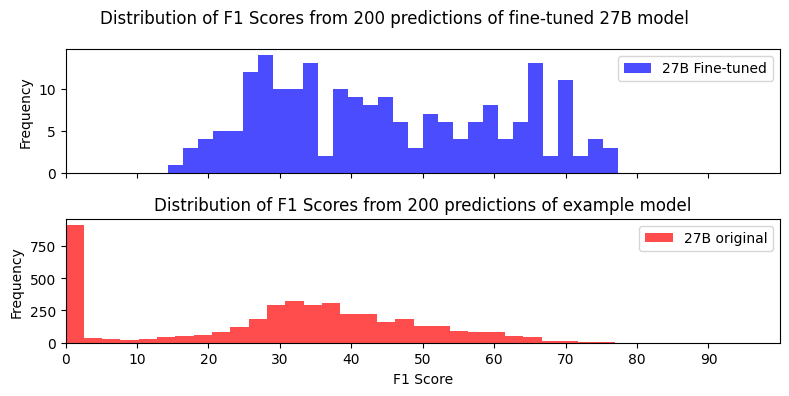

Tested 200 samples for 27B fine-tuned 

    F1 Mean: 44.50814876368534 F1 STD: 16.426081120667945 

    F1 Mean delta: 14.952373497539227 F1 STD delta: -2.9379497588073846
    


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv

f1score_lst_27b = []
with open("/u/lsong/labspace/lei_notebook/data/output_gemma-3-27b-it_200ct.pkl_Hospitalfinal.csv","r") as file:
    samples_10 = csv.reader(file, delimiter=',')
    next(samples_10)
    for rows in samples_10:
        float_n = float(rows[7])
        #if float_n>0:
        f1score_lst_27b.append(float_n)

f1score_lst_aaron = []
with open("/u/lsong/labspace/lei_notebook/data/output_gemma-3-27b-it_manuscript.pkl_Hospitalfinal.csv","r") as file:
    samples_10 = csv.reader(file, delimiter=',')
    next(samples_10)
    for rows in samples_10:
        float_n = float(rows[7])
        #if float_n>0:
        f1score_lst_aaron.append(float_n)       

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Row 1: Text modality
axes[0].hist(f1score_lst_27b, bins=30, color="blue", alpha=0.7, label="27B Fine-tuned")
axes[1].hist(f1score_lst_aaron, bins=30, color="red", alpha=0.7, label="27B original")

axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[0].set_ylabel("Frequency")
axes[0].legend()
# Set x-axis ticks to bin boundaries
plt.xticks(list(range(0, 100, 10)))
plt.xlim(0, 100)

# Labels and title
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.suptitle("Distribution of F1 Scores from 200 predictions of fine-tuned 27B model")
plt.title("Distribution of F1 Scores from 200 predictions of example model")
plt.tight_layout()
plt.show()


import statistics

# Calculate the standard deviation from a sample of data
print(
    f"""Tested {len(f1score_lst_27b)} samples for 27B fine-tuned \n
    F1 Mean: {statistics.mean(f1score_lst_27b)} F1 STD: {statistics.stdev(f1score_lst_27b)} \n
    F1 Mean delta: {(statistics.mean(f1score_lst_27b) - statistics.mean(f1score_lst_aaron))} F1 STD delta: {(statistics.stdev(f1score_lst_27b) - statistics.stdev(f1score_lst_aaron))}
    """)

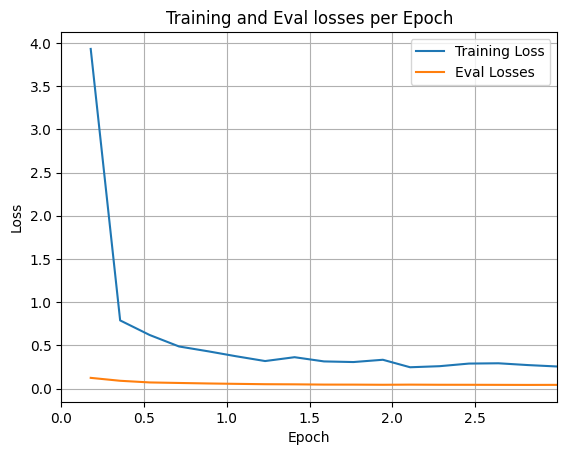

In [2]:
import json
import matplotlib.pyplot as plt

log_lst = []
with open("/.mounts/labs/courtotlab/scratch/lora/training.log",'r') as f:
    lines = f.readlines()
    for line in lines:
        log_lst.append(json.loads(line))

# Access the log history
log_history = sorted(log_lst, key=lambda d: d['epoch'])

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]

eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
eval_epoch = [log["epoch"] for log in log_history if "eval_loss" in log]

#option plot grad norm if available
#grad_norm = [log["grad_norm"] for log in log_history if "grad_norm" in log]
#gn_epoch = [log["epoch"] for log in log_history if "grad_norm" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(eval_epoch, eval_losses, label="Eval Losses")
#plt.plot(gn_epoch, grad_norm, label="Gradiant Norm")
plt.xlim(0,max(eval_epoch))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Eval losses per Epoch")
plt.legend()
plt.grid(True)
plt.show()